## DL Model Training

#### Import libraries

In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np, random
from google.colab import drive
drive.mount('/content/drive')

# 1. Set seeds
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# 2. Deterministic settings
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### Load Training Sets

In [2]:
X_train_final = pd.read_csv("/content/drive/My Drive/Colab Notebooks/data/X_train_final.csv")
X_test_final = pd.read_csv("/content/drive/My Drive/Colab Notebooks/data/X_test_final.csv")
X_val_final = pd.read_csv("/content/drive/My Drive/Colab Notebooks/data/X_val_final.csv")
y_train_final = pd.read_csv("/content/drive/My Drive/Colab Notebooks/data/y_train_final.csv")
y_test_final = pd.read_csv("/content/drive/My Drive/Colab Notebooks/data/y_test_final.csv")
y_val_final = pd.read_csv("/content/drive/My Drive/Colab Notebooks/data/y_val_final.csv")

In [3]:
# --- 1. Convert final datasets to PyTorch tensors ---
X_train_tensor = torch.tensor(X_train_final.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_final.values.reshape(-1,1), dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_final.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_final.values.reshape(-1, 1), dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_final.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_final.values.reshape(-1, 1), dtype=torch.float32)

In [4]:
# --- 2. Create PyTorch datasets and dataloaders ---
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 64
g = torch.Generator()
g.manual_seed(seed)  # fix seed for DataLoader shuffling

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,           # still shuffle for training
    num_workers=0,          # avoid parallel non-determinism
    generator=g
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)


In [5]:
# --- 3. Define a simple MLP model ---
class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden_sizes=[64,32], dropout=0.0):  # MODIFIED
        super(SimpleMLP, self).__init__()
        layers = []
        last_dim = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(last_dim, h))
            layers.append(nn.ReLU())
            if dropout > 0.0:  # ADDED
                layers.append(nn.Dropout(dropout))
            last_dim = h
        layers.append(nn.Linear(last_dim, 1))  # output for binary classification
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

input_dim = X_train_final.shape[1]
model = SimpleMLP(input_dim)

# --- 3b. Deep & Cross Network (DCN) ---
class CrossLayer(nn.Module):
    def __init__(self, input_dim):
        super(CrossLayer, self).__init__()
        self.weight = nn.Parameter(torch.randn(input_dim, 1))
        self.bias = nn.Parameter(torch.randn(input_dim))

    def forward(self, x):
        x0 = x                              # [batch, D]
        xw = torch.matmul(x, self.weight)   # [batch, 1]
        x_cross = x0 * xw + self.bias       # [batch, D]
        return x_cross


class DCN(nn.Module):
    def __init__(self, input_dim, deep_hidden=[64,32],dropout=0.0):
        super(DCN, self).__init__()
        self.cross = CrossLayer(input_dim)
        layers = []
        last_dim = input_dim
        for h in deep_hidden:
            layers.append(nn.Linear(last_dim, h))
            layers.append(nn.ReLU())
            if dropout > 0.0:  # ADDED
                layers.append(nn.Dropout(dropout))
            last_dim = h
        layers.append(nn.Linear(last_dim, 1))
        self.deep = nn.Sequential(*layers)

    def forward(self, x):
        x_cross = self.cross(x)              # [batch, D] now
        x_deep = self.deep(x)                # deep network outputs [batch, 1]
        combined = x_cross.sum(dim=1, keepdim=True) + x_deep
        return combined


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import roc_auc_score

# ---------------- Evaluate function ----------------
def evaluate_and_report(model, loader, criterion, device):
    """
    Evaluate a model on a given loader.
    Returns:
        - loss (average over batches)
        - accuracy
        - AUC score
    """
    model.eval()
    all_labels = []
    all_outputs = []
    total_loss = 0.0
    total_samples = 0
    correct = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_batch = y_batch.float().view(-1, 1)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item() * y_batch.size(0)

            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == y_batch).sum().item()
            total_samples += y_batch.size(0)

            all_labels.append(y_batch.cpu())
            all_outputs.append(torch.sigmoid(outputs).cpu())

    avg_loss = total_loss / total_samples
    acc = correct / total_samples
    all_labels = torch.cat(all_labels).numpy()
    all_outputs = torch.cat(all_outputs).numpy()
    auc = roc_auc_score(all_labels, all_outputs)

    return {"loss": avg_loss, "acc": acc, "auc": auc}

# ---------------- Train model ----------------
def train_model(
    model,
    train_loader,
    val_loader,
    test_loader=None,           # optional test loader
    epochs=100,
    lr=0.001,
    weight_decay=1e-4,
    patience=10,
    hyperparams={}
):

    # 1. Set seeds
    seed = 42
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # 2. Deterministic settings
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    """
    Train a PyTorch model with early stopping based on validation loss,
    tracking train/validation accuracy and AUC.
    Final test accuracy is evaluated after training.
    """
    model_name = model.__class__.__name__
    print(f"Training {model_name}...")

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_loss = float('inf')
    best_val_acc = 0.0
    best_val_auc = 0.0
    best_hyperparams = None
    best_model_state = None
    wait = 0
    device = next(model.parameters()).device

    for epoch in range(epochs):
        # ---------------- Training ----------------
        model.train()
        train_losses = []
        correct_train = 0
        total_train = 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_batch = y_batch.float().view(-1, 1)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct_train += (preds == y_batch).sum().item()
            total_train += y_batch.size(0)

        avg_train_loss = sum(train_losses)/len(train_losses)
        train_acc = correct_train / total_train

        # ---------------- Validation ----------------
        val_metrics = evaluate_and_report(model, val_loader, criterion, device)
        val_loss = val_metrics["loss"]
        val_acc = val_metrics["acc"]
        val_auc = val_metrics["auc"]

        # ---------------- Early stopping ----------------
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc
            best_val_auc = val_auc
            best_model_state = model.state_dict()
            best_hyperparams = hyperparams
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

        # ---------------- Print metrics ----------------
        if (epoch + 1) % 10 == 0 or epoch == epochs - 1:
            print(f"[{model_name}] Epoch {epoch+1}/{epochs} | "
                  f"Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | "
                  f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val AUC: {val_auc:.4f}")

    # ---------------- Load best model ----------------
    model.load_state_dict(best_model_state)
    model = model.to(device)

    # ---------------- Final test evaluation ----------------
    if test_loader is not None:
        test_metrics = evaluate_and_report(model, test_loader, criterion, device)
        test_acc = test_metrics["acc"]
    else:
        test_acc = None

    # ---------------- Summary ----------------
    print("-"*10)
    print(f"Best Val Acc: {best_val_acc:.4f} | Val AUC: {best_val_auc:.4f}")
    print(f"Best Hyperparameters: {best_hyperparams}")
    if test_acc is not None:
        print(f"Final Test Accuracy: {test_acc:.4f}")
    print("-"*20)

    # ---------------- Return metrics ----------------
    return {
        "model": model,
        "best_val_acc": best_val_acc,
        "best_val_auc": best_val_auc,
        "test_acc": test_acc,
        "best_hyperparams": best_hyperparams
    }

### Hyperparameter Tuning

In [8]:
import itertools

# ---------------- Hyperparameter ranges ----------------
hidden_sizes_options = [[64, 32], [128, 64], [32, 16]]
dropout_options = [0.0, 0.1, 0.2]
lr_options = [1e-3, 3e-4, 1e-4]
weight_decay_options = [1e-4, 1e-3, 1e-2]

# ---------------- Generate all combinations ----------------
configs = []
for hs, do, lr, wd in itertools.product(hidden_sizes_options,
                                        dropout_options,
                                        lr_options,
                                        weight_decay_options):
    configs.append({
        "hidden_sizes": hs,
        "dropout": do,
        "lr": lr,
        "weight_decay": wd
    })

print(f"Total hyperparameter combinations: {len(configs)}")


In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

hyperparameter_tuned_results = []
models_to_train = [                 # Hyperparameter tuning, 10 epochs only
    ("SimpleMLP", SimpleMLP, 10),
    ("DCN", DCN, 10)
]

for model_name, model_class, epochs in models_to_train:

    for cfg in configs:
        # --- Map the config keys based on model class ---
        if model_class == SimpleMLP:
            model = model_class(
                input_dim=X_train_final.shape[1],
                hidden_sizes=cfg.get("hidden_sizes", None),
                dropout=cfg["dropout"]
            )
        elif model_class == DCN:
            model = model_class(
                input_dim=X_train_final.shape[1],
                deep_hidden=cfg.get("hidden_sizes", None),  # map hidden_sizes -> deep_hidden
                dropout=cfg["dropout"]
            )
        else:
            raise ValueError(f"Unknown model class: {model_class}")

        model = model.to(device)

        result = train_model(
            model,
            train_loader,
            val_loader,
            test_loader,
            epochs=epochs,
            lr=cfg["lr"],
            weight_decay=cfg["weight_decay"],
            patience=10,
            hyperparams=cfg
        )
        result["model_name"] = model_name
        hyperparameter_tuned_results.append(result)


In [10]:
records = []
for r in hyperparameter_tuned_results:
    records.append({
        "Model": r["model_name"],
        "Best Params": r["best_hyperparams"],
        "Validation Accuracy": r["best_val_acc"],
        "Validation AUC": r["best_val_auc"],
        "Test Accuracy": r["test_acc"]   # <-- updated
    })

df_results = pd.DataFrame(records)
df_results = df_results.sort_values(by="Validation Accuracy", ascending=False)
df_results


In [ ]:
df_results.to_csv("/content/drive/My Drive/Colab Notebooks/data/hyperparameter_tuning_results.csv", index=False)

In [ ]:
df_results = pd.read_csv("/content/drive/My Drive/Colab Notebooks/data/DL_hyperparameter_tuned_results.csv")
# 2. Convert DataFrame back into a list of dictionaries
hyperparameter_tuned_results = df_results.to_dict(orient="records")

# Now `records` has the same format as your original `hyperparameter_tuned_results`
print(hyperparameter_tuned_results[:3])  # preview the top 3

In [13]:
# Suppose all quick search results are in this list
results = hyperparameter_tuned_results

# Get best SimpleMLP
best_mlp = max(
    [r for r in results if r["Model"] == "SimpleMLP"],
    key=lambda x: x["Validation Accuracy"]
)

# Get best DCN
best_dcn = max(
    [r for r in results if r["Model"] == "DCN"],
    key=lambda x: x["Validation Accuracy"]
)

# Print summary
for r in [best_mlp, best_dcn]:
    print(f"Best {r['Model']}:")
    print("  Hyperparameters:", r["Best Params"])
    print("  Validation Accuracy:", r["Validation Accuracy"])
    print("  Validation AUC:", r["Validation AUC"])
    print("-"*30)

Best SimpleMLP:
  Hyperparameters: {'hidden_sizes': [128, 64], 'dropout': 0.0, 'lr': 0.001, 'weight_decay': 0.01}
  Validation Accuracy: 0.859752670039348
  Validation AUC: 0.8086492215238583
------------------------------
Best DCN:
  Hyperparameters: {'hidden_sizes': [128, 64], 'dropout': 0.1, 'lr': 0.001, 'weight_decay': 0.001}
  Validation Accuracy: 0.8478077571669477
  Validation AUC: 0.7513764533407645
------------------------------


### Retrain the Best Model Fully

In [14]:
import ast

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# --- Best SimpleMLP ---
mlp_cfg = mlp_cfg = ast.literal_eval(best_mlp["Best Params"])
final_mlp = SimpleMLP(
    input_dim=X_train_final.shape[1],
    hidden_sizes=mlp_cfg["hidden_sizes"],
    dropout=mlp_cfg["dropout"]
).to(device)

final_mlp_result = train_model(
    final_mlp,
    train_loader,
    val_loader,
    test_loader,
    epochs=100,             # full training
    lr=mlp_cfg["lr"],
    weight_decay=mlp_cfg["weight_decay"],
    patience=15,
    hyperparams=mlp_cfg
)

# --- Best DCN ---
dcn_cfg = dcn_cfg = ast.literal_eval(best_dcn["Best Params"])
final_dcn = DCN(
    input_dim=X_train_final.shape[1],
    deep_hidden=dcn_cfg["hidden_sizes"],  # note DCN uses deep_hidden
    dropout=dcn_cfg["dropout"]
).to(device)

final_dcn_result = train_model(
    final_dcn,
    train_loader,
    val_loader,
    test_loader,
    epochs=200,             # maybe longer for DCN
    lr=dcn_cfg["lr"],
    weight_decay=dcn_cfg["weight_decay"],
    patience=20,
    hyperparams=dcn_cfg
)

Using device: cpu
Training SimpleMLP...
[SimpleMLP] Epoch 10/100 | Train Loss: 0.2760 | Val Loss: 0.4078 | Train Acc: 0.8819 | Val Acc: 0.8205 | Val AUC: 0.8071
[SimpleMLP] Epoch 20/100 | Train Loss: 0.2267 | Val Loss: 0.4713 | Train Acc: 0.9049 | Val Acc: 0.7962 | Val AUC: 0.7875
Early stopping at epoch 28
----------
Best Val Acc: 0.8667 | Val AUC: 0.8146
Best Hyperparameters: {'hidden_sizes': [128, 64], 'dropout': 0.0, 'lr': 0.001, 'weight_decay': 0.01}
Final Test Accuracy: 0.8438
--------------------
Training DCN...
[DCN] Epoch 10/200 | Train Loss: 4.9954 | Val Loss: 2.9514 | Train Acc: 0.7552 | Val Acc: 0.8067 | Val AUC: 0.7794
[DCN] Epoch 20/200 | Train Loss: 2.7657 | Val Loss: 2.9827 | Train Acc: 0.7962 | Val Acc: 0.7345 | Val AUC: 0.7787
[DCN] Epoch 30/200 | Train Loss: 1.6391 | Val Loss: 1.5804 | Train Acc: 0.8191 | Val Acc: 0.8558 | Val AUC: 0.7745
[DCN] Epoch 40/200 | Train Loss: 1.0458 | Val Loss: 1.1577 | Train Acc: 0.8350 | Val Acc: 0.8204 | Val AUC: 0.7716
[DCN] Epoch 50/

In [15]:
# Combine fully trained results
final_results = [final_mlp_result, final_dcn_result]

# Pick the best model by validation accuracy (or you could use Val AUC)
best_result = max(final_results, key=lambda x: x["best_val_acc"])

best_model = best_result["model"]

print("Best Model:", best_result.get("model_name", type(best_model).__name__))
print("Best Validation Accuracy:", best_result["best_val_acc"])
print("Best Validation AUC:", best_result["best_val_auc"])
print("Final Test Accuracy:", best_result["test_acc"])
print("Best Hyperparameters:", best_result["best_hyperparams"])

Best Model: SimpleMLP
Best Validation Accuracy: 0.8667088251826869
Best Validation AUC: 0.8145783970163348
Final Test Accuracy: 0.8438136724513454
Best Hyperparameters: {'hidden_sizes': [128, 64], 'dropout': 0.0, 'lr': 0.001, 'weight_decay': 0.01}


## Model Evaluation

In [16]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [17]:
def get_predictions_and_labels(loader, model, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            # Binary classification
            if outputs.shape[1] == 1:
                preds = (torch.sigmoid(outputs) > 0.5).int()

            # Multi-class classification
            else:
                preds = torch.argmax(outputs, dim=1)

            all_preds.append(preds.cpu())
            all_labels.append(y_batch.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    return all_preds, all_labels

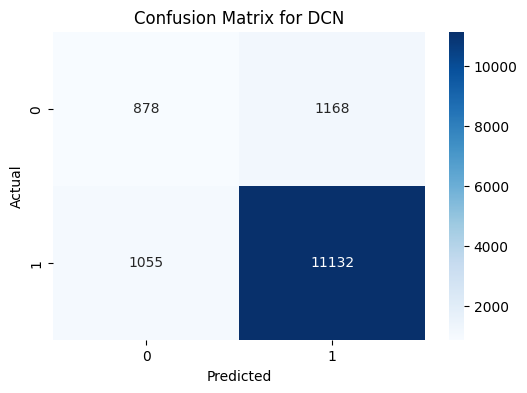


Classification Report:
               precision    recall  f1-score   support

         0.0     0.4542    0.4291    0.4413      2046
         1.0     0.9050    0.9134    0.9092     12187

    accuracy                         0.8438     14233
   macro avg     0.6796    0.6713    0.6753     14233
weighted avg     0.8402    0.8438    0.8420     14233



In [18]:
# Make sure best_model is on the same device as your data
best_model = best_model.to(device)

# Evaluate on test set
y_pred, y_true = get_predictions_and_labels(test_loader, best_model, device)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix for DCN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification report
cr = classification_report(y_true, y_pred, digits=4)
print("\nClassification Report:\n", cr)
